# Import Packages

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, 
    classification_report, precision_recall_curve, f1_score
)

# Utils

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, 
    classification_report, precision_recall_curve, f1_score
)

def load_test_data(file_path='./data/processed/final_feature_bundle.joblib'):
    """1. Load tập dữ liệu test đã qua xử lý."""
    if not os.path.exists(file_path):
        print(f"❌ Không tìm thấy file dữ liệu tại: {file_path}")
        return None, None
    data = joblib.load(file_path)
    return data['X_test'], data['y_test']

def load_best_model(model_name_keyword='Logistic_Regression', folder_path='./models'):
    """
    2. Load model có AUC cao nhất từ nhật ký benchmark.
    Đã sửa lỗi khớp tên cột 'auc_score'.
    """
    benchmark_file = os.path.join(folder_path, 'model_benchmark_history.csv')
    if not os.path.exists(benchmark_file):
        print(f"❌ Không tìm thấy file: {benchmark_file}")
        return None
    
    # Đọc file history
    history_df = pd.read_csv(benchmark_file)
    
    # Lọc theo keyword (ví dụ 'XGBoost', 'Logistic_Regression')
    filtered_df = history_df[history_df['model_name'].str.contains(model_name_keyword, case=False)]
    
    if filtered_df.empty:
        print(f"⚠️ Không tìm thấy model nào chứa từ khóa: {model_name_keyword}")
        return None
    
    # SỬA LỖI TẠI ĐÂY: Dùng đúng tên cột 'auc_score' từ file CSV của bạn
    best_info = filtered_df.sort_values(by='auc_score', ascending=False).iloc[0]
    
    model_path = os.path.join(folder_path, best_info['file_path'])
    
    try:
        model = joblib.load(model_path)
        print(f"🚀 Đã Load thành công: {best_info['file_path']}")
        print(f"📊 AUC ghi nhận: {best_info['auc_score']:.4f}")
        return model
    except Exception as e:
        print(f"❌ Lỗi khi load file vật lý: {e}")
        return None

# 1. Func: Đánh giá chất lượng mô hình

In [15]:
def evaluate_model_performance(model, X_test, y_test):
    """
    Đánh giá toàn diện mô hình trên tập Test.
    """
    # 1. Lấy xác suất dự báo (Probability) thay vì nhãn 0/1
    y_probs = model.predict_proba(X_test)[:, 1]
    
    # 2. Tính toán ROC và AUC
    fpr, tpr, thresholds_roc = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    
    # 3. Tính toán Precision-Recall
    precision, recall, thresholds_pr = precision_recall_curve(y_test, y_probs)
    
    # --- TRỰC QUAN HÓA ---
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # Biểu đồ ROC
    ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[0].set_title('Receiver Operating Characteristic (ROC)')
    ax[0].set_xlabel('Tỷ lệ báo động giả (False Positive Rate)')
    ax[0].set_ylabel('Tỷ lệ bắt đúng nợ xấu (True Positive Rate)')
    ax[0].legend(loc="lower right")
    
    # Biểu đồ Precision-Recall
    ax[1].plot(recall, precision, color='blue', lw=2, label='P-R Curve')
    ax[1].set_title('Precision-Recall Curve')
    ax[1].set_xlabel('Recall (Khả năng bao phủ nợ xấu)')
    ax[1].set_ylabel('Precision (Độ tin cậy khi dự báo xấu)')
    ax[1].legend(loc="lower left")
    
    plt.show()
    return y_probs

# 2. Xác định threshold

In [16]:
def find_best_threshold(y_true, y_probs):
    """Tìm ngưỡng tối ưu để đạt F1-score cao nhất."""
    thresholds = np.arange(0.1, 0.9, 0.01)
    f1_scores = [f1_score(y_true, y_probs >= t) for t in thresholds]
    
    best_t = thresholds[np.argmax(f1_scores)]
    print(f"🎯 Ngưỡng cắt tối ưu (Best Threshold): {best_t:.2f}")
    return best_t

def plot_final_confusion_matrix(y_true, y_probs, threshold):
    """Vẽ ma trận nhầm lẫn dựa trên ngưỡng đã chọn."""
    y_pred = (y_probs >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Dự báo Tốt', 'Dự báo Xấu'], 
                yticklabels=['Thực tế Tốt', 'Thực tế Xấu'])
    plt.title(f'Confusion Matrix (Threshold = {threshold:.2f})')
    plt.show()
    
    print("\n--- BÁO CÁO CHI TIẾT ---")
    print(classification_report(y_true, y_pred))

# Main Flow

🚀 Đã Load thành công: Logistic_Regression_AUC07458_20260319_0934.joblib
📊 AUC ghi nhận: 0.7458


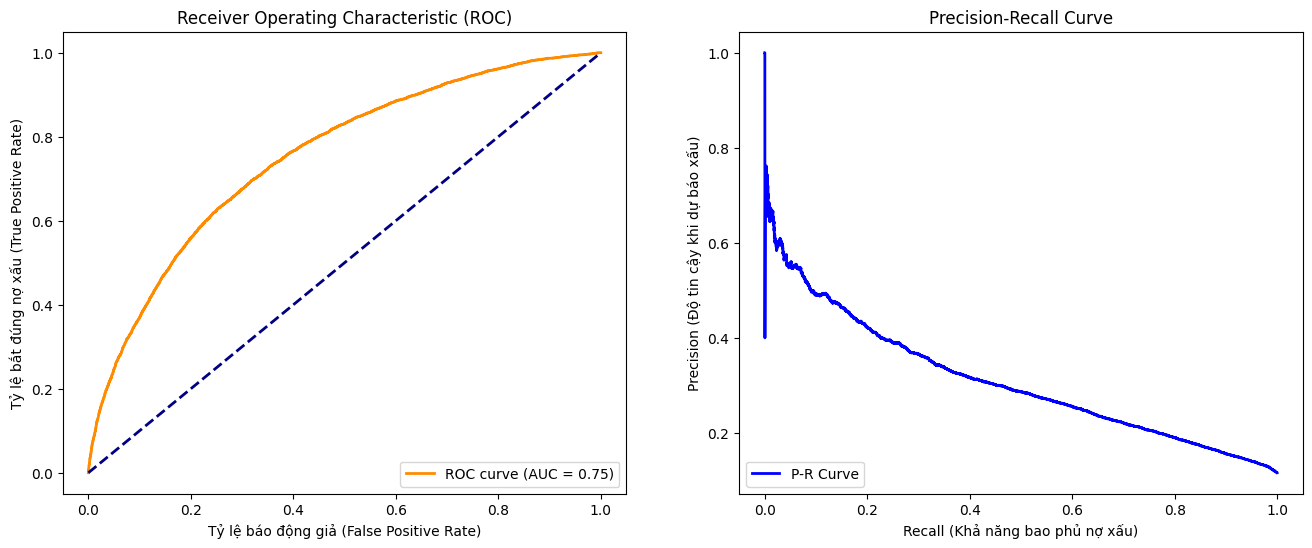

🎯 Ngưỡng cắt tối ưu (Best Threshold): 0.62


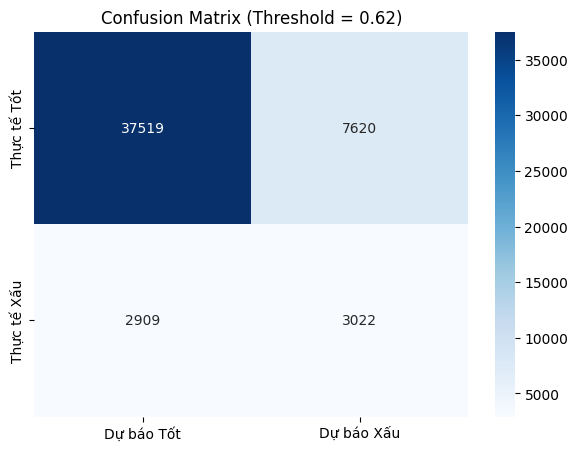


--- BÁO CÁO CHI TIẾT ---
              precision    recall  f1-score   support

           0       0.93      0.83      0.88     45139
           1       0.28      0.51      0.36      5931

    accuracy                           0.79     51070
   macro avg       0.61      0.67      0.62     51070
weighted avg       0.85      0.79      0.82     51070



In [22]:
# --- STEP 1 & 2: Load Data & Model ---
X_test, y_test = load_test_data()
best_model = load_best_model(model_name_keyword='Logistic_Regression') # Hoặc 'Random_Forest'

if best_model and X_test is not None:
    # --- STEP 3: Đánh giá tổng quát ---
    y_probs = evaluate_model_performance(best_model, X_test, y_test)
    
    # --- STEP 4: Tìm ngưỡng cắt thông minh ---
    opt_threshold = find_best_threshold(y_test, y_probs)
    
    # --- STEP 5: Xem kết quả thực chiến ---
    plot_final_confusion_matrix(y_test, y_probs, opt_threshold)